In [1]:
pip install kagglehub


  Obtaining dependency information for kagglehub from https://files.pythonhosted.org/packages/a4/8e/4077b08b95a1f8302c694a8b399bd413815fbe89045c41e6e08cd7d9439a/kagglehub-0.3.13-py3-none-any.whl.metadata
  Using cached kagglehub-0.3.13-py3-none-any.whl.metadata (38 kB)
  Obtaining dependency information for pyyaml from https://files.pythonhosted.org/packages/86/bf/899e81e4cce32febab4fb42bb97dcdf66bc135272882d1987881a4b519e9/pyyaml-6.0.3-cp312-cp312-win_amd64.whl.metadata
  Using cached pyyaml-6.0.3-cp312-cp312-win_amd64.whl.metadata (2.4 kB)
Using cached kagglehub-0.3.13-py3-none-any.whl (68 kB)
Using cached pyyaml-6.0.3-cp312-cp312-win_amd64.whl (154 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


# Análisis del Comportamiento de Compra y Proposición de Valor de Suscripción 🛒

Resumen:
Este proyecto tiene como objetivo segmentar la base de clientes para evaluar la relación entre la frecuencia de compra , el gasto promedio y el estado de suscripción . El análisis se centra en determinar si el programa de suscripción está impulsando la lealtad y la satisfacción , identificando áreas críticas para la intervención estratégica de marketing y producto.

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
file_path = "shopping_behavior_updated.csv"
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "rehan497/customer-shopping-behavior-dataset",
  file_path,
)


C:\Users\Usuario\AppData\Local\Temp\ipykernel_20152\793480138.py:2: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [4]:
print(df.head())


   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        Location Size      Color  Season  Review Rating Subscription Status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Yes   
2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
4         Oregon    M  Turquoise  Spring            2.7                 Yes   

   Shipping Type Discount Applied Promo Code Used  Previ

In [5]:
total_ventas = df["Item Purchased"]
total_ganancia = df["Purchase Amount (USD)"]
total_articulos_vendidos_valor = total_ventas.count() 
total_ganancia_valor = total_ganancia.sum()

In [6]:
print(f"En total se vendieron: {total_articulos_vendidos_valor} artículos, y la ganancia total fue de ${total_ganancia_valor:.2f} USD")

En total se vendieron: 3900 artículos, y la ganancia total fue de $233081.00 USD


# Información
Se tiene conocimiento que a la fecha en que se trabaja con los datos En total se vendieron: 3900 artículos, y la ganancia total fue de $233081.00 USD

In [7]:
suscripcion = df["Subscription Status"]
conteo_suscripcion = suscripcion.value_counts()
id = df["Customer ID"].count()
print(f"En total se tuvo: {id} clientes")
print(f"Tabla de suscripción:\n{conteo_suscripcion}")


En total se tuvo: 3900 clientes
Tabla de suscripción:
Subscription Status
No     2847
Yes    1053
Name: count, dtype: int64


# Información
En total de 3900 clientes solo 1053 poseen una suscripción

In [8]:
productos_vendidos = df["Item Purchased"]
categorias = df["Category"]
categorias_total = categorias.value_counts()
print("--- Conteo de Categorías de Artículos ---")
print(f"{categorias_total}")

--- Conteo de Categorías de Artículos ---
Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64


# Información
Los productos mas vendidos han sido productos de las tiendas de ropa seguido por las tiendas de accesorios  representando estas el 44,54% y 31,79% respectivamente de las ventas totales

In [9]:
analisis_gasto = df.groupby('Frequency of Purchases').agg(
    Gasto_Promedio_USD=('Purchase Amount (USD)', 'mean'),
    Total_Transacciones=('Customer ID', 'count')
).sort_values(by='Gasto_Promedio_USD', ascending=False)

conteo_suscripcion = df.pivot_table(
    index='Frequency of Purchases', 
    columns='Subscription Status',   
    values='Customer ID',         
    aggfunc='count',
    fill_value=0                   
)

print("gasto promedio por categoría de frecuencia de compra:")
print(analisis_gasto)
print("\n" + "="*70 + "\n")
print("Conteo de suscripción por categoría de frecuencia:")
print(conteo_suscripcion)

gasto promedio por categoría de frecuencia de compra:
                        Gasto_Promedio_USD  Total_Transacciones
Frequency of Purchases                                         
Bi-Weekly                        60.694698                  547
Annually                         60.173077                  572
Every 3 Months                   60.082192                  584
Quarterly                        59.984014                  563
Monthly                          59.330922                  553
Fortnightly                      59.053506                  542
Weekly                           58.972171                  539


Conteo de suscripción por categoría de frecuencia:
Subscription Status      No  Yes
Frequency of Purchases          
Annually                412  160
Bi-Weekly               407  140
Every 3 Months          430  154
Fortnightly             389  153
Monthly                 404  149
Quarterly               423  140
Weekly                  382  157


C:\Users\Usuario\AppData\Local\Temp\ipykernel_20152\3243869010.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


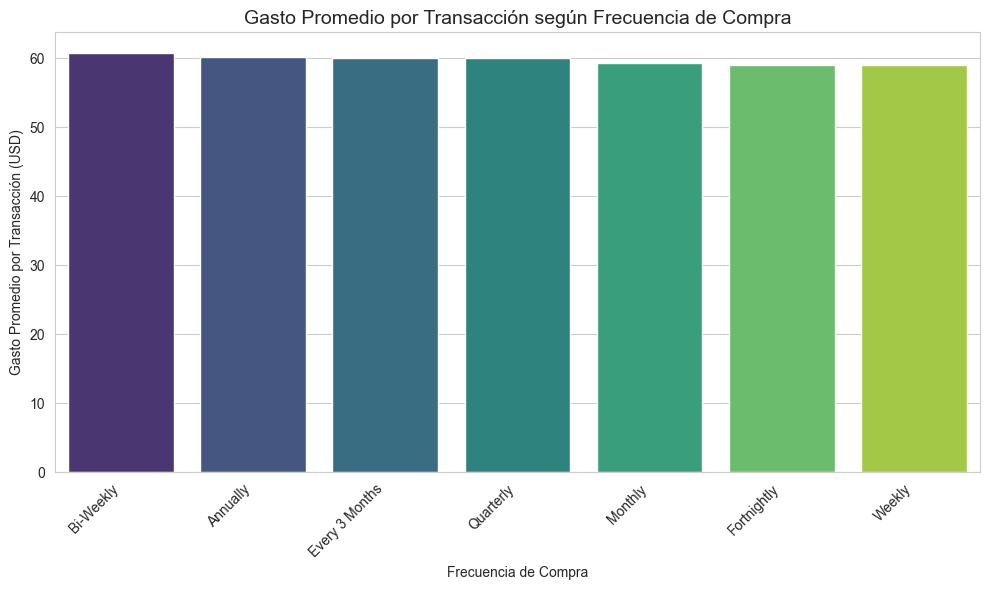

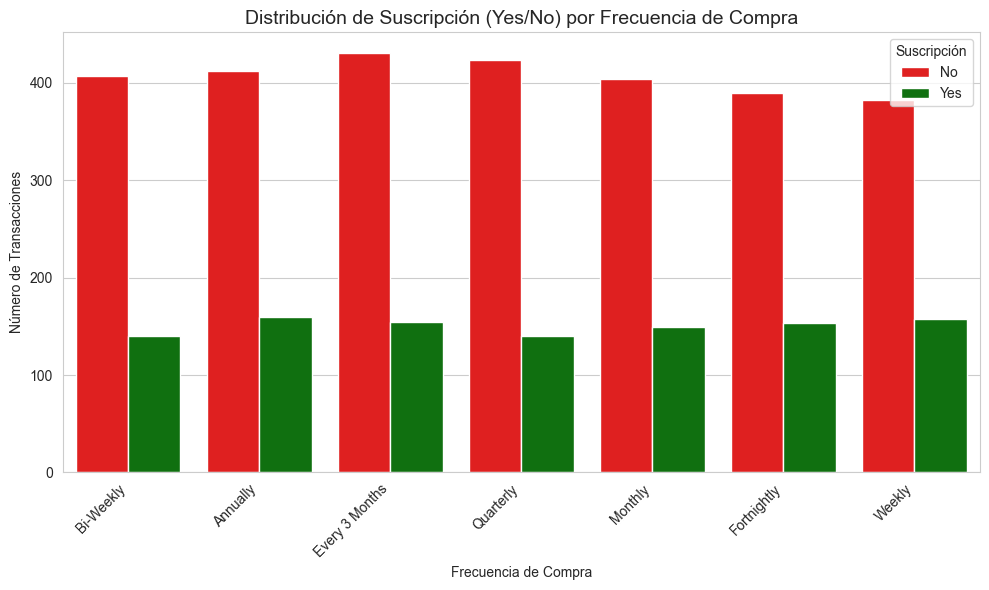

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df_gasto_ordenado = analisis_gasto.sort_values(by='Gasto_Promedio_USD', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=df_gasto_ordenado.index, 
    y='Gasto_Promedio_USD', 
    data=df_gasto_ordenado,
    palette='viridis'
)

plt.title('Gasto Promedio por Transacción según Frecuencia de Compra', fontsize=14)
plt.xlabel('Frecuencia de Compra')
plt.ylabel('Gasto Promedio por Transacción (USD)')
plt.xticks(rotation=45, ha='right') 
plt.tight_layout() 
plt.show()

df_suscripcion_reseteado = conteo_suscripcion.reset_index()

df_plot = df_suscripcion_reseteado.melt(
    id_vars='Frequency of Purchases',
    value_vars=['No', 'Yes'],
    var_name='Estado_Suscripcion',
    value_name='Conteo'
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Frequency of Purchases',
    y='Conteo',
    hue='Estado_Suscripcion', 
    data=df_plot,
    palette={'Yes': 'green', 'No': 'red'},
    order=df_gasto_ordenado.index 
)

plt.title('Distribución de Suscripción (Yes/No) por Frecuencia de Compra', fontsize=14)
plt.xlabel('Frecuencia de Compra')
plt.ylabel('Número de Transacciones')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Suscripción')
plt.tight_layout()
plt.show()

### Hallazgo Clave: Gasto Uniforme y Oportunidad de Crecimiento 💰

El gráfico de Gasto Promedio por Transacción revela una variación mínima (aproximadamente entre 50 a 60 USD a través de todas las categorías de frecuencia de compra.

Esto demuestra una baja correlación entre la frecuencia de compra de un cliente y el valor promedio de su carrito. El negocio no está logrando que los clientes menos frecuentes  realicen compras significativamente más grandes que los clientes más frecuentes. El potencial de crecimiento en ingresos  no está en aumentar el valor de la transacción individual, sino en impulsar la frecuencia de compra y la conversión a suscripción.

### Segmentación de Lealtad vs. Compromiso 

La distribución de Suscripción (`Yes`/`No`) a través de las categorías de frecuencia es el pilar de este análisis:

Validación de Lealtad: Las categorías de mayor frecuencia "Weekly" y "Fortnightly" muestran la mayor proporción de clientes suscritos (la sección verde de las barras), confirmando que el hábito de compra regular es un fuerte predictor de la propensión al compromiso.
Oportunidad: A pesar de esto, la porción más grande en todas las categorías es consistentemente No Suscritos. Los clientes de alta frecuencia no suscritos representan el segmento de mayor valor potencial, ya que ya tienen el hábito de compra y solo necesitan un incentivo de suscripción que justifique el cambio.


In [12]:
rating = df.groupby('Frequency of Purchases')['Review Rating'].mean().sort_values(ascending=False)

print("Calificación Promedio por Frecuencia de Compra:")
print(rating)

Calificación Promedio por Frecuencia de Compra:
Frequency of Purchases
Monthly           3.776311
Every 3 Months    3.767295
Weekly            3.759555
Annually          3.755944
Fortnightly       3.755166
Quarterly         3.727531
Bi-Weekly         3.706947
Name: Review Rating, dtype: float64


In [13]:
rating = df.groupby('Subscription Status')['Review Rating'].mean().sort_values(ascending=False)

print("Calificación Promedio por Estado de Suscripción:")
print(rating)

Calificación Promedio por Estado de Suscripción:
Subscription Status
No     3.752722
Yes    3.742450
Name: Review Rating, dtype: float64


### Alerta  de Satisfacción:
El análisis de satisfacción revela que el promedio de Rating es ligeramente inferior para los clientes Suscritos en comparación con los No Suscritos. Esto constituye un riesgo de abandono por lo que si el programa de suscripción no mejora la experiencia del cliente ni su satisfacción, los beneficios percibidos no justifican el compromiso, lo que impacta negativamente en la retención a largo plazo.

  Informe Ejecutivo y Recomendaciones Estratégicas
Conclusiones:
Clave del Análisis de ClientesGasto: El valor promedio por transacción es uniforme en todas las categorías de frecuencia aporximadamente $60 USD. El foco para la rentabilidad debe ser la frecuencia de compra y no el aumento del gasto unitario.
Lealtad: La propensión a la suscripción es más alta en los clientes de mayor frecuencia ( 'Weekly' y 'Fortnightly' ), confirmando que la lealtad es un factor de conversión clave.
Riesgo (Satisfacción): La satisfacción de los Suscritos es ligeramente menor que la de los No Suscritos, lo que indica una urgente necesidad de revisión de los beneficios del programa de fidelidad.
Recomendaciones Estratégicas: Realizar encuestas a Suscriptores para determinar por qué su satisfacción no es superior. Ademas, dado que la mayoria de las compras son en tiendas de ropa y accesorio se sugiere realizar una campaña de marketing para mejorar las ventas de calzado y ropa de calle dado sus bajos indices de ventas siendo estas 2 solo de un 15,36% para el calzado y un 8,31% para la ropa de calle
